In [38]:
import numpy as np
from matplotlib import pyplot as plt
import scipy

np.random.seed(378)

In [ ]:
#general function for taking a step in a Markov chain with a finite number of states,
#takes as input the current state and the probability transition matrix

def step(current, T_matrix):

    cumul_prob = np.cumsum(T_matrix[current])
    p = np.random.random() #extracting random number between 0 and 1
    
    for i in range(len(cumul_prob)):
        if p <= cumul_prob[i]:
            return i
        else:
            continue

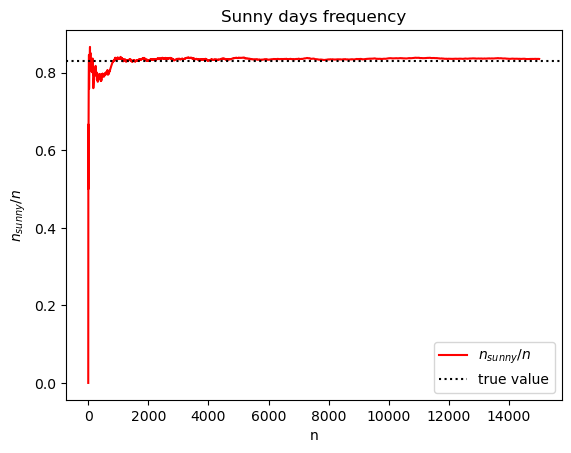

In [ ]:

# 0 = rainy, 1 = sunny

N = 15000 #number of days considered (# steps in the chain)
T_matrix = [[0.5, 0.5], [0.1, 0.9]] #transition prob matrix

n_clear = 0
clear_freq = []
current = 0 #initial state (in this case a rainy day)

n_vals = np.arange(2, N)

#running the Markov chain  
for n in n_vals:
    
    current = step(current, T_matrix)
    n_clear = n_clear + current
    clear_freq.append(n_clear/n)

th_pclear = 0.83 #true value 

#trace plot of the sunny days frequency
plt.plot(n_vals, clear_freq, c='r', label='$n_{sunny}/n$')
plt.axhline(th_pclear, linestyle='dotted', c='black', label='true value')
plt.xlabel('n')
plt.ylabel('$n_{sunny}/n$')
plt.title('Sunny days frequency')
plt.legend()






Text(0.5, 1.0, 'Distribution of the frequencies')

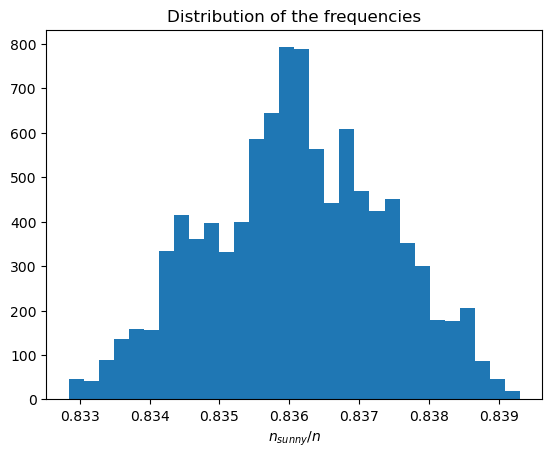

In [137]:
burn_in = 5000 # ~number of steps to reach stationarity

#plotting the distribution of the values, discarding the burn in
plt.hist(clear_freq[burn_in:], 30)
plt.xlabel('$n_{sunny}/n$')
plt.title('Distribution of the frequencies')

In [ ]:
#computing the mean and standard deviation as summary statistics for the distribution
mean = np.mean(clear_freq[burn_in:])
err = np.std(clear_freq[burn_in:])

#our best numerical estimate for the probability of a day being sunny
print(str(mean)+' +- '+str(err))

0.8361094108931441 +- 0.001282869639171473
